In [3]:
# Enable autoreload of local Python modules (e.g., models)
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time

# local imports
import models as models
import generation as generation


In [5]:
# initialize the jax random key
key = jax.random.key(0)

# Load data

In [6]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./text8_train.txt", "r") as f:
    train_text = f.read()
with open("./text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [7]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [8]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [9]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

of paran or the pomeranian pommersch dialect spoken in many different parts of southern brazil in the states of rio grande do su

 game has also been spoofed by the onion in an issue which showed in six steps how kevin bacon is linked to al qaeda also it was

g tension differs so much between solo and orchestral tuning that a different set of strings is required therefore the strings a

 four book our knowledge of the external world as a field for scientific method in philosophy among the several schools that wer

ve the book was reportedly written in the early one nine eight zero s but didn t receive the uk government s approval for public



# Create a basic Transformer model

In [10]:
def create_train_state(rng, vocab_size=27, d_model=64, n_layers=6, n_heads=8, max_len=128):
    # create a basic Transformer model
    model = models.DecoderOnlyTransformer(vocab_size, d_model, n_layers, n_heads, max_len)
    # create a dummy input for initialization
    dummy = jnp.zeros((1, min(16, max_len)), dtype=jnp.int32)
    # pass the dummy input to the model to initialize the parameters
    params = model.init({"params": rng}, dummy)["params"]
    return model, params

In [11]:
# vocab size
vocab_size= len(char_set)

# internal model dimensions
d_model=256

# number of attention heads
n_heads=8

# number of Transformer layers
n_layers=2

# maximum sequence length
max_len=128

model, params = create_train_state(key, vocab_size, d_model, n_layers, n_heads, max_len)

In [12]:
# compute the number of parameters
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters: {count_params(params):_}")

Number of parameters: 1_624_576


In [13]:
# sanity check: create a batch of data & run a forward pass
B, T = 4, 32
batch = jax.random.randint(
    key=key,
    shape=(B, T), minval=0, maxval=len(char_set))
logits = model.apply({"params": params}, batch)

print("batch shape:", batch.shape)  # (B, T)
print("logits shape:", logits.shape)  # (B, T, vocab_size)

batch shape: (4, 32)
logits shape: (4, 32, 27)


# Loss function

In [14]:
@jax.jit
def loss_and_metrics(logits, targets):
    """Compute cross-entropy loss and accuracy.

    Assumes `targets` contains only valid integer class ids in [0, V-1] (no -1 ignore tokens).

    Args:
      logits: (B, T, V) float array of unnormalized scores.
      targets: (B, T) integer array with ground-truth class ids.

    Returns:
      loss: scalar average cross-entropy over all positions.
      metrics: dict with keys "loss" and "acc" (both scalars).
    """
    # Flatten batch/time dims so optax works on shape (N, V) and (N,)
    vocab = logits.shape[-1]
    flat_logits = logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)

    # Per-position cross-entropy, then mean over all positions
    per_pos = optax.softmax_cross_entropy_with_integer_labels(flat_logits, flat_targets)
    loss = per_pos.mean()

    # prediction over all positions
    preds = jnp.argmax(logits, axis=-1)  # (B, T)

    # compute accuracy over only the last position
    is_match = preds == targets

    # Accuracy over all positions
    acc_all = jnp.mean(is_match.astype(jnp.float32))

    # Accuracy over only last position
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:,-1])

    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}

# Optimization step:

In [15]:
# create an update function
def train_step(params, opt_state, x, y, tx):
    """Single optimization step using optax optimizer.

    Args:
      params: pytree of model parameters.
      opt_state: optax optimizer state corresponding to `params`.
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
      tx: optax.GradientTransformation (already initialized).

    Returns:
      new_params: updated parameters after one gradient step.
      new_opt_state: updated optimizer state.
      metrics: dict of scalar metrics (loss, acc).
    """
    def loss_fn(params):
        logits = model.apply({"params": params}, x)
        loss, metrics = loss_and_metrics(logits, y)
        return loss, metrics

    # compute gradients (loss is scalar, metrics is auxiliary)
    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # optax update: compute parameter updates and new optimizer state
    updates, new_opt_state = tx.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, metrics

# jit: last argument should be static because it is an object
train_step = jax.jit(train_step, static_argnames=("tx",))

# Batch creation:

In [16]:
# create a batch from the training data
def get_batch(text_int, B, T):
    """Create a random batch of data from text_int.

    Args:
      text_int: 1D array of token ids.
      B: batch size (number of sequences).
      T: sequence length (number of tokens per sequence).

    Returns:
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
    """
    # choose random starting indices for each sequence in the batch
    ix = np.random.randint(0, len(text_int) - T, size=B)
    # inputs are text from i to i+T
    x = np.stack([text_int[i:i+T] for i in ix])
    # targets are text from i+1 to i+T+1
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

# Optimizer creation:

In [22]:
def transformer_lr_schedule(d_model, warmup_steps=4000):
    """Noam learning rate schedule from 'Attention Is All You Need'.

    lrate = d_model^{-0.5} * min(step^{-0.5}, step * warmup^{-1.5})
    """
    def schedule(step):
        # avoid zero division error
        step = jnp.maximum(step, 1)

        inv_sqrt_step = step ** -0.5
        scaled_step = step * (warmup_steps ** -1.5)

        return (d_model ** -0.5) * jnp.minimum(inv_sqrt_step, scaled_step)

    return schedule


In [23]:
warmup_steps = 4000

# Noam learning rate schedule
learning_rate_schedule = transformer_lr_schedule(d_model=d_model,
                                                 warmup_steps=warmup_steps)

# Adam with Transformer-paper hyperparameters
tx = optax.adam(
    learning_rate=learning_rate_schedule,
    b1=0.9,
    b2=0.98,
    eps=1e-9,
)

# Initialize optimizer state for current params
opt_state = tx.init(params)
print(f"Initialized optimizer: Adam with Noam schedule, "
      f"d_model={d_model}, warmup_steps={warmup_steps}")




Initialized optimizer: Adam with Noam schedule, d_model=256, warmup_steps=4000


In [24]:
niter = 100_000
B, T = 128, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']

    loss_history.append(loss)
    time_history.append(time.time() - time_start)

    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()


iteration 0  time: 3.8 seconds
	 	 loss(train :: test): 1.3103 :: 1.2727
	 	 accuracy (train :: test): 58.5% :: 59.7%
	 	 accuracy (last character) (train :: test): 53.9% :: 62.4%

iteration 2_000  time: 41.1 seconds
	 	 loss(train :: test): 1.2675 :: 1.2774
	 	 accuracy (train :: test): 60.2% :: 59.9%
	 	 accuracy (last character) (train :: test): 64.1% :: 62.3%

iteration 4_000  time: 74.7 seconds
	 	 loss(train :: test): 1.3207 :: 1.2773
	 	 accuracy (train :: test): 58.4% :: 59.8%
	 	 accuracy (last character) (train :: test): 61.7% :: 63.4%

iteration 6_000  time: 109.7 seconds
	 	 loss(train :: test): 1.2767 :: 1.2849
	 	 accuracy (train :: test): 59.2% :: 59.6%
	 	 accuracy (last character) (train :: test): 60.2% :: 60.9%

iteration 8_000  time: 144.4 seconds
	 	 loss(train :: test): 1.2673 :: 1.2855
	 	 accuracy (train :: test): 59.7% :: 59.5%
	 	 accuracy (last character) (train :: test): 64.1% :: 63.1%

iteration 10_000  time: 178.9 seconds
	 	 loss(train :: test): 1.2610 :: 

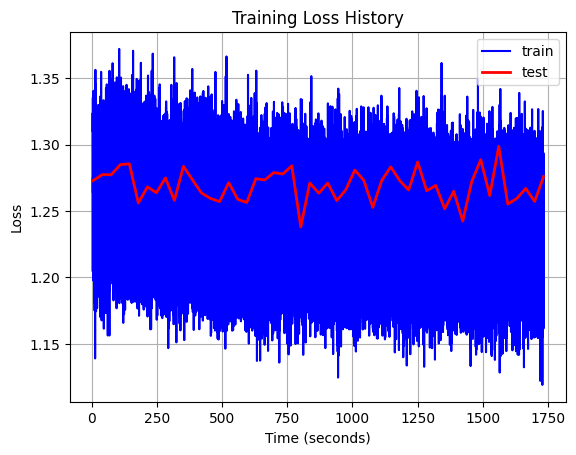

In [26]:
# plot the loss history
import matplotlib.pyplot as plt
plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

In [27]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
# prompt_int = encode(prompt.lower())
prompt_int = jnp.array([ [char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generation.generate_tokens(model, params, rng, prompt_int, gen_len, block_size=64,
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 1000)
generated text:
hello my fri ie sh ando ae a h sh ki de midlengatanandedestrp es chr thach b rich ch d ma ou uclonoret mamaid inasinon tw s gis qeral ay s a wan icu ano wonoreleridan ameloadit wellas rig an wo anouis s on trionttz atedifistolarinschorester tupoumachi ghu on an scithys a e f wonto us g oul c t gis p bcabru st alono pranonaiso koreret i s manai palac toial charone s inses thev ps ci wrd colili brothiel fle win aronetha sh adgad anes aber ma henaler c akind s olare cineargid marus timin bilene onistos bul stha bimahes ft s itor n s hacumasd inana g ararerad ost in ckelenelil s weladis win wirmanscondech prisechery iterelithele by p kateranatoypiagie a ane comacot a apine alaromatogozrins eniden s ones cocoth ws atis ut birrelitharairarromaledsaran blllar the osh s ch all ano s arrd w ensherir adreleckreline areskolins tragg mamalllelide a hy wwu o goryliaroonathas ch hmerus sthowaraniders pan t rin t haves marin ande wohert s f es mis ansine